# Sur-apprentissage, biais et variance - KMAXPP05

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

## Fonctions

In [2]:
def creer_echantillon(n, sigma=15., biais=0.):
    X = np.random.normal(185., 10., (n, 1))  # la taille est générée à partir d'une loi normal de moyenne 185 et d'écart type 10
    epsilon = np.random.normal(biais, sigma, (n, 1))  # le bruit est généré à partir d'une loi normal centrée sur un biais systémique
    Y = -80. + X + epsilon
    return X, Y

In [3]:
def tracer_echantillon(X, Y, rugby=True):
    plt.scatter(X, Y, edgecolor="w", s=100)
    if rugby:
        plt.xlabel("taille [cm]")
        plt.ylabel("poids [kg]")

In [4]:
def tracer_modele(X=None, Y=None, beta=None, true_beta=None, ci=False, rugby=True):
    if rugby:
        Xi = np.linspace(160., 210., 1000).reshape(-1, 1)
    else:
        Xi = np.linspace(-6., 6., 1000).reshape(-1, 1)
    if np.ndim(beta) == 3:
        degres = beta.shape[1] - 1
    elif np.ndim(beta) == 2:
        degres = beta.shape[0] - 1
    Xi_tilde = phi(Xi, degres=degres)
    Yi_hat = Xi_tilde @ beta
    if X is not None and Y is not None:
        plt.scatter(X, Y, edgecolor="w", s=100, zorder=10, label="Données")
    if np.ndim(Yi_hat) == 2:
        plt.plot(Xi, Yi_hat, label=r"$\hat{f}$")
    elif np.ndim(Yi_hat) == 3:
        if not ci:
            for i in range(Yi_hat.shape[0]):
                plt.plot(Xi, Yi_hat[i,:,:], color="k", alpha=0.1)
        else:
            mean = Yi_hat.mean(axis=0).ravel()
            std = Yi_hat.std(axis=0).ravel()
            plt.plot(Xi.ravel(), mean, color="k", label=r"$\hat{f}$ moyen")
            plt.fill_between(Xi.ravel(), mean - 1.96 * std, mean + 1.96 * std, color="k", alpha=0.2, label="95% IC")
    if true_beta is not None:
        plt.plot(Xi, phi(Xi, degres=true_beta.shape[0]-1) @ true_beta, color="green", label=r"Fonction vraie $f$")
    plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
    if rugby:
        plt.xlabel("taille [cm]")
        plt.ylabel("poids [kg]")
        plt.xlim(160., 210.)
        plt.ylim(60., 160.)

In [5]:
def tracer_biais_variance(beta, true_beta, rugby=True):
    if rugby:
        Xi = np.linspace(160., 210., 1000).reshape(-1, 1)
    else:
        Xi = np.linspace(-6., 6., 1000).reshape(-1, 1)
    if np.ndim(beta) == 3:
        degres = beta.shape[1] - 1
    elif np.ndim(beta) == 2:
        degres = beta.shape[0] - 1
    Xi_tilde = phi(Xi, degres=degres)
    Yi_hat = Xi_tilde @ beta
    Y = phi(Xi, degres=true_beta.shape[0] - 1) @ true_beta
    biais = ((Yi_hat - Y).mean(axis=0))**2
    variance = Yi_hat.var(axis=0)
    plt.plot(Xi, biais, label="biais")
    plt.plot(Xi, variance, label="variance")
    plt.legend()
    if rugby:
        plt.xlabel("taille [cm]")
        plt.ylabel(r"$\text{poids}^2$ [$\text{kg}^2$]")
        plt.yscale("log")
        plt.xlim(160., 210.)

In [6]:
def phi(X, degres=1):
    # Fonction d'augmentation de l'espace X à l'espace X tilde
    entrees = [np.ones_like(X)]
    for i in range(1, degres+1):
        entrees.append(X**i)
    return np.hstack(entrees)

In [7]:
def moindres_carres(X_tilde, Y):
    # Resolution de la méthode des moindres carrés grâce à une décomposition QR
    # R @ beta = Q.T @ Y
    Q, R = np.linalg.qr(X_tilde)
    beta_hat = sp.linalg.solve_triangular(R, Q.T @ Y, lower=False)
    return beta_hat

## Exemple

In [8]:
np.random.seed(16)

In [9]:
X, Y = creer_echantillon(n=4)

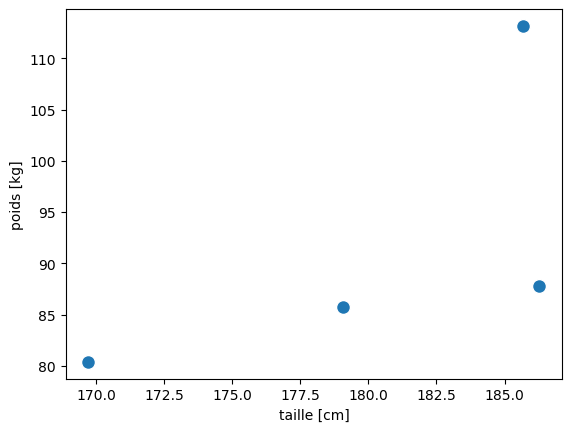

In [10]:
tracer_echantillon(X, Y)

In [11]:
X_tilde = phi(X)

In [12]:
beta_hat = moindres_carres(X_tilde, Y)

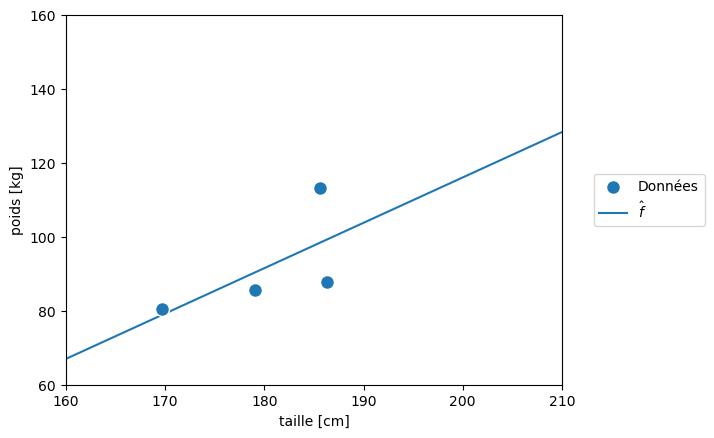

In [13]:
tracer_modele(X, Y, beta_hat)

## Dépendence aux données d'apprentissage

In [14]:
true_beta=np.array([[-80.], [1.]])

In [15]:
m = 100    # nombre de modèles
n = 4      # nombre d'observations
d = 1      # degrés du polynôme
biais = 0. # biais systémique (espérance conditionelle de epsilon)

In [16]:
beta_hat_arr = []
for i in range(m):
    X, Y = creer_echantillon(n=n, biais=biais)
    X_tilde = phi(X, degres=d)
    beta_hat = moindres_carres(X_tilde, Y)
    beta_hat_arr.append(beta_hat)
beta_hat_arr = np.array(beta_hat_arr)

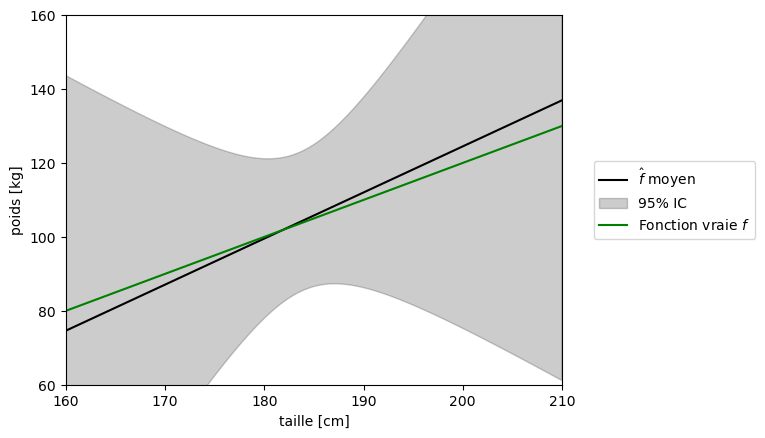

In [17]:
tracer_modele(X=None, Y=None, beta=beta_hat_arr, true_beta=true_beta, ci=True)

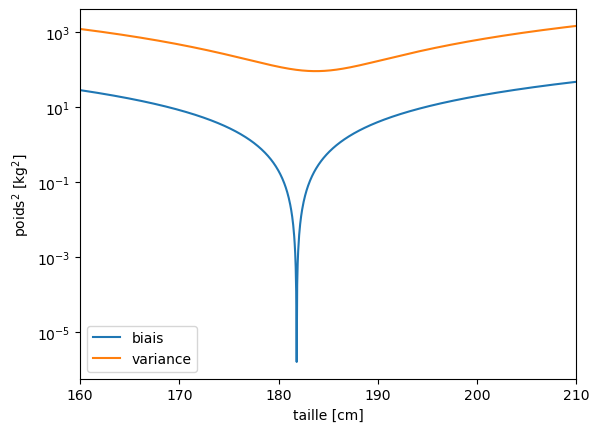

In [18]:
tracer_biais_variance(beta_hat_arr, true_beta)

## Biais de modèle

In [19]:
def creer_echantillon_2(n, sigma=0.3, biais=0.):
    X = np.random.normal(0., 3., (n, 1))
    epsilon = np.random.normal(biais, sigma, (n, 1))
    Y = 0.01 * X**3 + epsilon
    return X, Y

In [20]:
true_beta=np.array([[0.], [0.], [0.], [0.01]])

In [21]:
m = 100    # nombre de modèles
n = 10   # nombre d'observations
d = 1     # degrés du polynôme
biais = 0. # biais systémique (espérance conditionelle de epsilon)

In [22]:
beta_hat_arr = []
for i in range(m):
    X, Y = creer_echantillon_2(n=n, biais=biais)
    X_tilde = phi(X, degres=d)
    beta_hat = moindres_carres(X_tilde, Y)
    beta_hat_arr.append(beta_hat)
beta_hat_arr = np.array(beta_hat_arr)

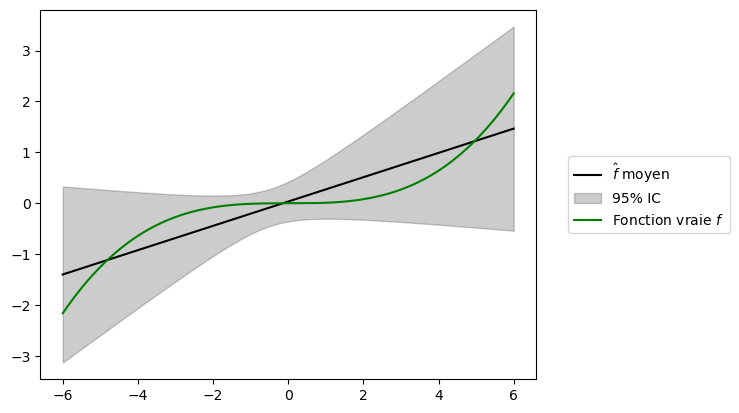

In [23]:
tracer_modele(X=None, Y=None, beta=beta_hat_arr, true_beta=true_beta, ci=True, rugby=False)

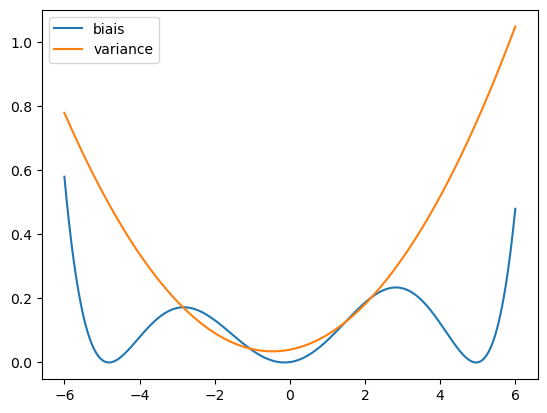

In [24]:
tracer_biais_variance(beta_hat_arr, true_beta, rugby=False)